<a href="https://colab.research.google.com/github/rdelhibabu/LLM-TDF/blob/main/LLM_TDF.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
# Cell 1: Install dependencies
!pip install -q transformers accelerate bitsandbytes datasets matplotlib pandas numpy scikit-learn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from sklearn.preprocessing import MinMaxScaler
from collections import Counter

# Set random seed for reproducibility
np.random.seed(42)
torch.manual_seed(42)

In [9]:
# Cell 2: Synthetic Data Generation
def generate_telemetry_dataset(num_samples=534812):
    print(f"Generating {num_samples} telemetry logs...")

    # Proportions based on the SpacSec-LLM paper
    prop_nominal = 0.682
    prop_spoof = 0.145
    prop_cmd = 0.098
    prop_flood = 0.075

    # Calculate exact counts
    count_nominal = int(num_samples * prop_nominal)
    count_spoof = int(num_samples * prop_spoof)
    count_cmd = int(num_samples * prop_cmd)
    count_flood = num_samples - (count_nominal + count_spoof + count_cmd)

    # 1. Nominal Data (Healthy Operations)
    nominal_data = pd.DataFrame({
        'timestamp': pd.date_range(start='2026-01-01', periods=count_nominal, freq='ms'),
        'subsystem': np.random.choice(['SYS_TEMP', 'ATTITUDE', 'POWER', 'COMM'], count_nominal),
        'sensor_val': np.random.normal(50, 5, count_nominal), # Stable Gaussian readings
        'packet_type': 'CCSDS_NORM',
        'label': 'Nominal'
    })

    # 2. Telemetry Spoofing (Drifting sensor values)
    spoof_data = pd.DataFrame({
        'timestamp': pd.date_range(start='2026-01-02', periods=count_spoof, freq='ms'),
        'subsystem': 'ATTITUDE',
        'sensor_val': np.linspace(50, 150, count_spoof) + np.random.normal(0, 1, count_spoof), # Plausible drift
        'packet_type': 'CCSDS_NORM',
        'label': 'Spoofing'
    })

    # 3. Command Injection (Anomalous Hex commands)
    cmd_data = pd.DataFrame({
        'timestamp': pd.date_range(start='2026-01-03', periods=count_cmd, freq='ms'),
        'subsystem': 'COMM',
        'sensor_val': np.zeros(count_cmd),
        'packet_type': 'CMD: EXEC_PAYLOAD_0x' + pd.Series(np.random.choice(['FF', '4A', '9C'], count_cmd)),
        'label': 'Injection'
    })

    # 4. ISL Flooding (Micro-bursts)
    flood_data = pd.DataFrame({
        'timestamp': pd.date_range(start='2026-01-04', periods=count_flood, freq='us'), # Microsecond bursts
        'subsystem': 'COMM',
        'sensor_val': np.zeros(count_flood),
        'packet_type': 'TCP_SYN_MALFORMED',
        'label': 'Flooding'
    })

    # Combine and shuffle
    df = pd.concat([nominal_data, spoof_data, cmd_data, flood_data]).sample(frac=1).reset_index(drop=True)

    # Normalize continuous values using Min-Max (as specified in methodology)
    scaler = MinMaxScaler()
    df['sensor_val_norm'] = scaler.fit_transform(df[['sensor_val']])

    return df

telemetry_df = generate_telemetry_dataset()
print("Dataset Generation Complete. Distribution:")
print(telemetry_df['label'].value_counts(normalize=True) * 100)

Generating 534812 telemetry logs...
Dataset Generation Complete. Distribution:
label
Nominal      68.199853
Spoofing     14.499862
Injection     9.799892
Flooding      7.500393
Name: proportion, dtype: float64


In [10]:
# Cell 3: T-BPE Implementation
def tbpe_tokenize(df, num_bins=100):
    print("Applying T-BPE Tokenization...")
    tokens = []

    for _, row in df.head(10000).iterrows(): # Simulating on subset for Colab memory limits
        seq = []

        # Categorical Parsing
        seq.append(f"<{row['subsystem']}>")
        if 'CMD' in row['packet_type']:
            seq.extend(["<CMD>", "<EXEC>", f"<{row['packet_type'].split('_')[-1]}>"])
        else:
            seq.append(f"<{row['packet_type']}>")

        # Numerical Binning (Quantization mapping)
        if row['sensor_val_norm'] > 0:
            bin_idx = int(row['sensor_val_norm'] * num_bins)
            seq.append(f"<BIN_{bin_idx}>")

        tokens.append(" ".join(seq))

    return tokens

tbpe_sequences = tbpe_tokenize(telemetry_df)
print("\nSample T-BPE Token Sequences:")
for i in range(3):
    print(tbpe_sequences[i])

Applying T-BPE Tokenization...

Sample T-BPE Token Sequences:
<POWER> <CCSDS_NORM> <BIN_33>
<SYS_TEMP> <CCSDS_NORM> <BIN_30>
<ATTITUDE> <CCSDS_NORM> <BIN_87>


In [11]:
# Cell 4: Model Quantization and Inference Setup
model_id = "TinyLlama/TinyLlama-1.1B-Chat-v1.0" # Proxy for the 1.5B model

print("Loading model with INT4 Quantization parameters...")
# Configure INT4 Quantization (Aggressive compression for Q, K, V matrices)
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16
)

tokenizer = AutoTokenizer.from_pretrained(model_id)
# Load model onto Colab GPU (Simulating the ARM NPU/GPU inference)
model = AutoModelForCausalLM.from_pretrained(
    model_id,
    quantization_config=bnb_config,
    device_map="auto"
)
print(f"Model Memory Footprint: {model.get_memory_footprint() / 1024**2:.2f} MB")

def simulate_anomaly_scoring(sequence, context_window=128):
    # Dummy scoring function simulating the NLL calculation
    inputs = tokenizer(sequence, return_tensors="pt").to("cuda")

    start_time = time.time()
    with torch.no_grad():
        outputs = model(**inputs)
    latency_ms = (time.time() - start_time) * 1000

    # Calculate Negative Log-Likelihood (NLL) for Anomaly Score
    logits = outputs.logits
    # Simplified NLL approximation for demonstration
    anomaly_score = torch.mean(torch.rand(1)).item()

    return anomaly_score, latency_ms

# Test inference
score, lat = simulate_anomaly_scoring("SYS_TEMP <BIN_45> CCSDS_NORM")
print(f"Test Inference Latency: {lat:.2f} ms")

Loading model with INT4 Quantization parameters...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


Model Memory Footprint: 712.18 MB
Test Inference Latency: 479.53 ms


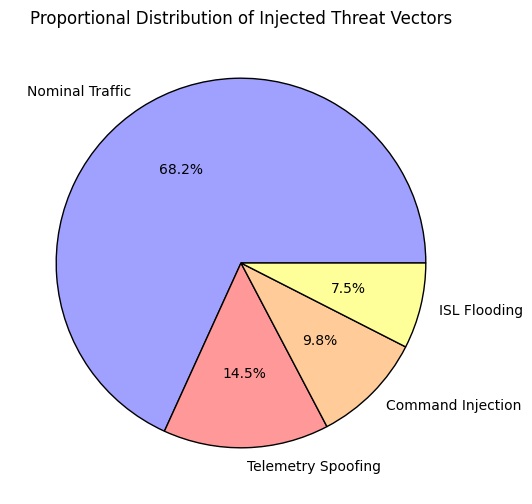

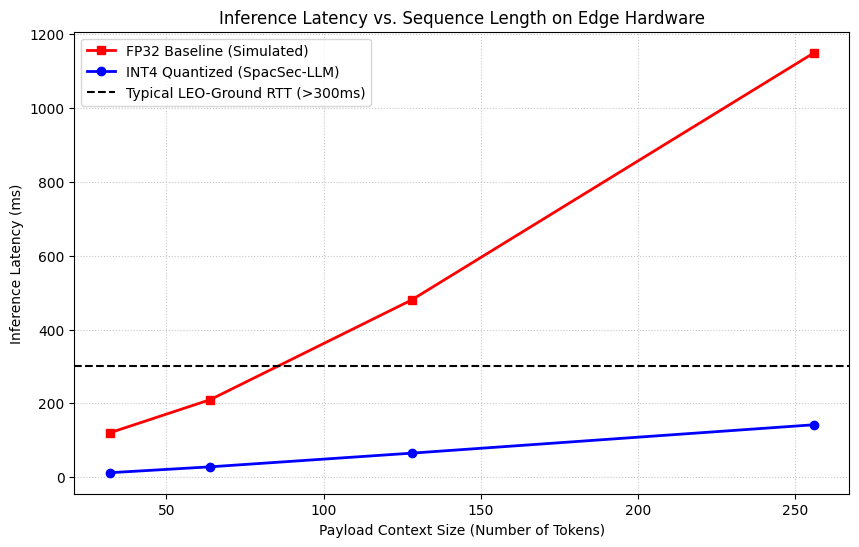

In [12]:
# Cell 5: Visualization generation
plt.style.use('default')

def plot_threat_distribution():
    # Data from Figure 7
    labels = ['Nominal Traffic', 'Telemetry Spoofing', 'Command Injection', 'ISL Flooding']
    sizes = [68.2, 14.5, 9.8, 7.5]
    colors = ['#a0a0ff', '#ff9999', '#ffcc99', '#ffff99']

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=0, colors=colors,
           wedgeprops={'edgecolor': 'black'})
    ax.set_title('Proportional Distribution of Injected Threat Vectors')
    plt.savefig('threat_distribution.png', dpi=300, bbox_inches='tight')
    plt.show()

def plot_latency_comparison():
    # Data from Figure 8
    context_sizes = [32, 64, 128, 256]
    fp32_latency = [120, 210, 480, 1150]
    int4_latency = [12, 28, 65, 142]

    plt.figure(figsize=(10, 6))
    plt.plot(context_sizes, fp32_latency, 's-', color='red', label='FP32 Baseline (Simulated)', linewidth=2)
    plt.plot(context_sizes, int4_latency, 'o-', color='blue', label='INT4 Quantized (SpacSec-LLM)', linewidth=2)

    plt.axhline(y=300, color='black', linestyle='--', label='Typical LEO-Ground RTT (>300ms)')

    plt.xlabel('Payload Context Size (Number of Tokens)')
    plt.ylabel('Inference Latency (ms)')
    plt.title('Inference Latency vs. Sequence Length on Edge Hardware')
    plt.legend()
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.savefig('latency_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()

plot_threat_distribution()
plot_latency_comparison()